# Credit Risk Prediction using Machine Learning

## Project Overview

This project builds a machine learning model to predict whether a borrower is likely to default on a loan based on their personal, financial, and loan-related information.

The project follows an end-to-end machine learning workflow including:

- Data loading and exploration
- Exploratory Data Analysis (EDA)
- Missing value handling
- Feature preprocessing
- Categorical encoding
- Feature scaling
- Model training using Random Forest
- Hyperparameter tuning using GridSearchCV
- Model evaluation using multiple classification metrics
- Feature importance analysis
- Model saving for future deployment

## Problem Statement

Financial institutions need to assess the risk associated with providing loans to borrowers. Incorrectly identifying a high-risk borrower as safe may result in financial losses.

The objective of this project is to build a classification model that predicts whether a borrower will default on a loan.

## Target Variable

`loan_status`

- `0` → No Default
- `1` → Default

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Joblib

## Machine Learning Workflow

Data Collection → EDA → Data Preprocessing → Train-Test Split → Model Training → Hyperparameter Tuning → Model Evaluation → Feature Importance → Model Saving

## 1. Import Required Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

## 2. Load the Dataset

In [2]:
df = pd.read_csv("credit_risk_dataset.csv")

# Display first five rows
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 3. Initial Data Exploration

In this section, we examine the dataset structure, feature names, data types, summary statistics, and missing values.

In [3]:
df.shape

(32581, 12)

In [4]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [7]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


## 4. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the distribution of the target variable, numerical features, correlations, and categorical variables.

In [8]:
df['loan_status'].value_counts()
# Distribution of loan status

,count
loan_status,
0,25473
1,7108


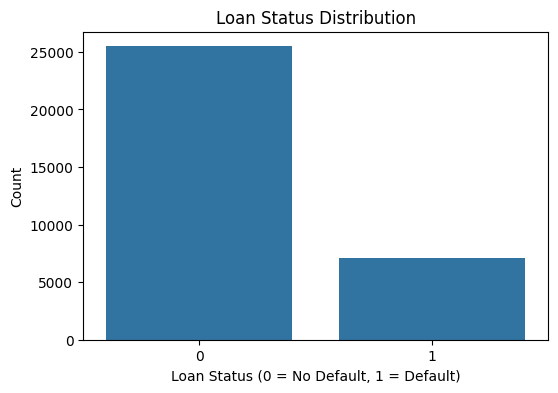

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x='loan_status', data=df)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status (0 = No Default, 1 = Default)")
plt.ylabel("Count")

plt.show()
#This tells us whether the dataset is balanced or imbalanced. If one class dominates, we'll keep that in mind when evaluating the model.

In [10]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


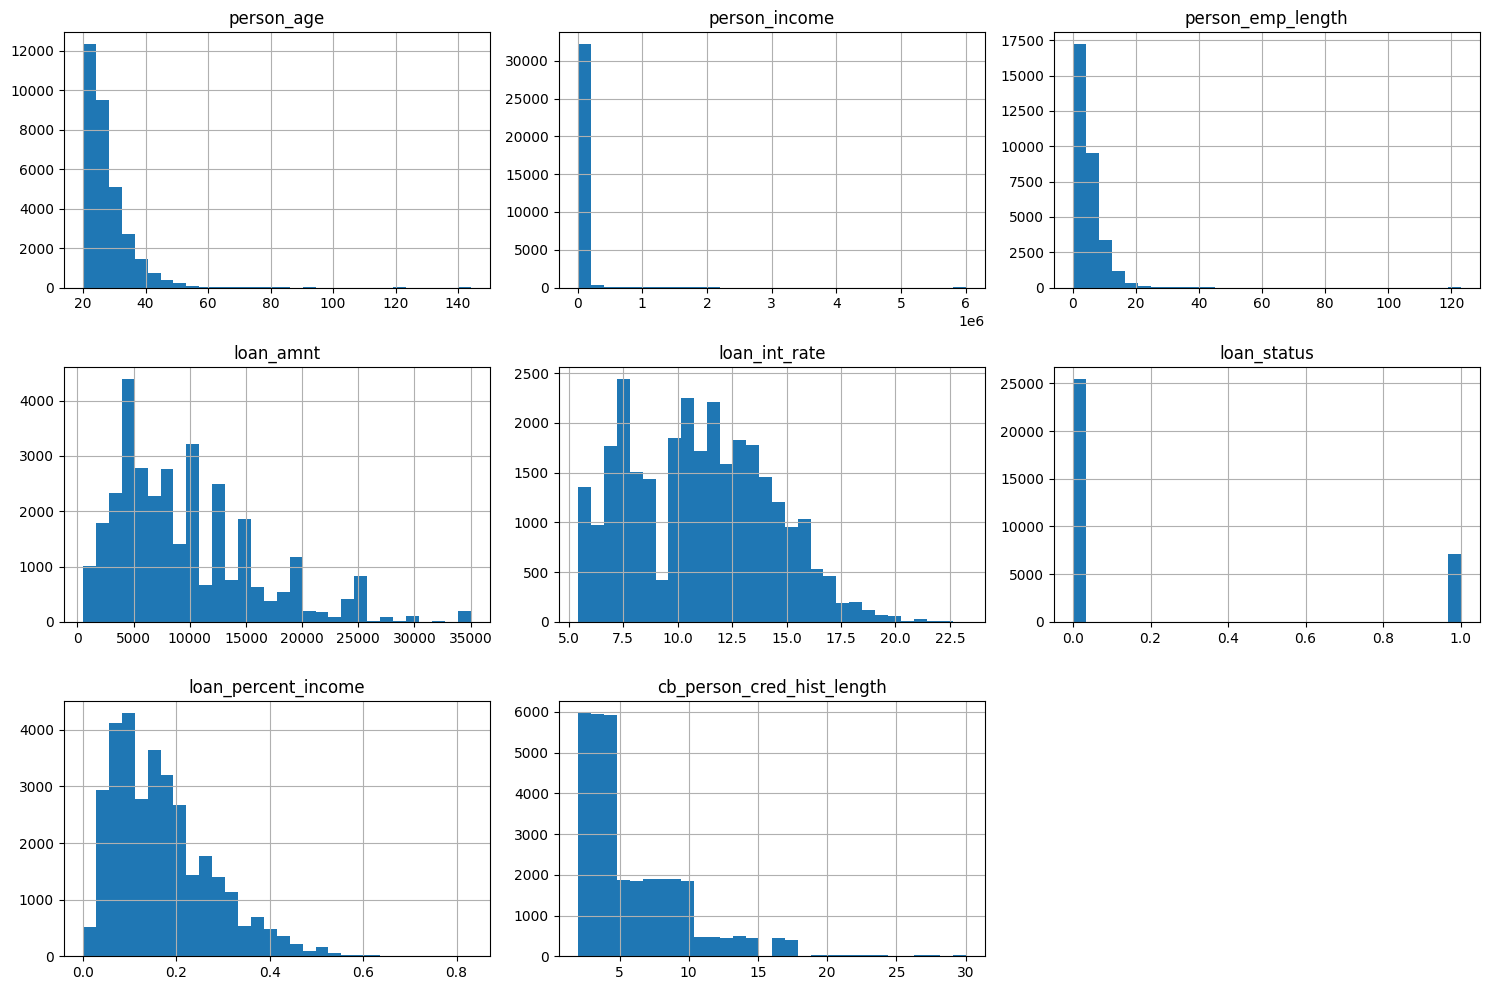

In [11]:
df.hist(figsize=(15,10), bins=30)

plt.tight_layout()
plt.show()

# Histograms show:
# The distribution of each numerical feature.


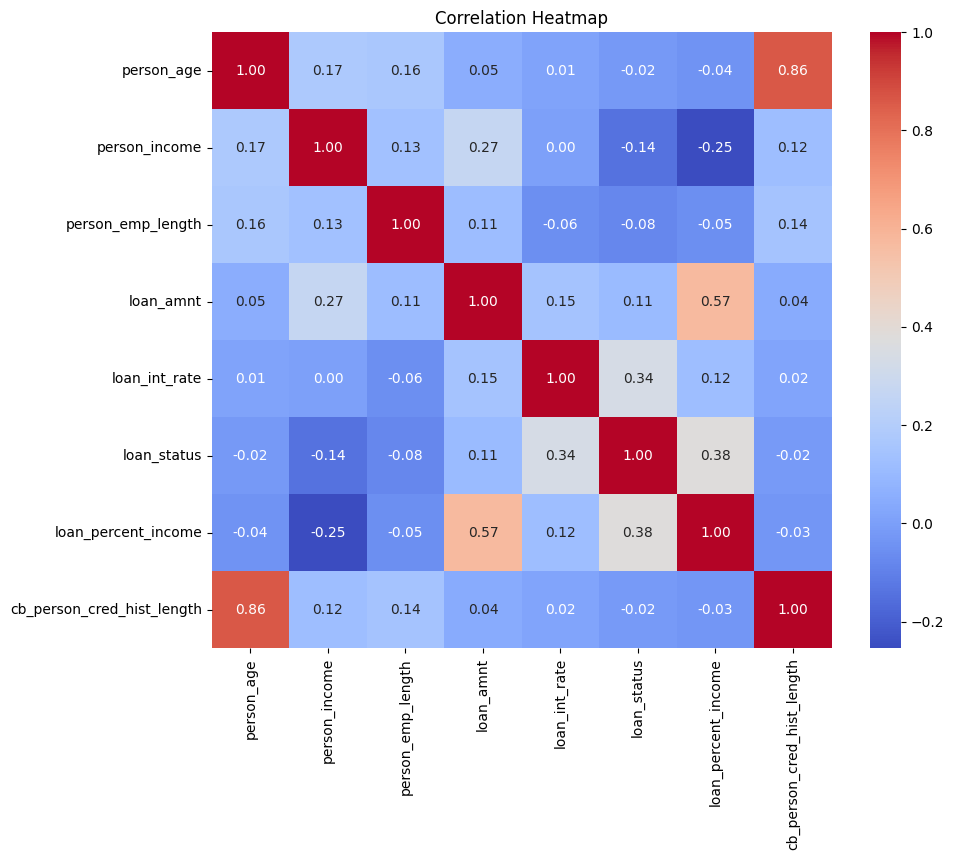

In [12]:
plt.figure(figsize=(10,8))
corr = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [13]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print("\n", "="*40)

    print(df[col].value_counts())



person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


## 5. Define Features and Target Variable

In [14]:
# Features (X) and Target (y)

X = df.drop('loan_status', axis=1)
y = df['loan_status']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (32581, 11)
Target Shape: (32581,)


## 6. Split the Dataset

The dataset is divided into training and testing sets.

- Training Set: 80%
- Testing Set: 20%

Stratified sampling is used to preserve the original distribution of the target classes.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (26064, 11)
Testing Set: (6517, 11)


In [16]:
# Numerical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')

Categorical Features:
Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')


## 7. Data Preprocessing Pipeline

Different preprocessing strategies are applied to numerical and categorical features.

### Numerical Features
- Missing values are replaced using the median.
- Features are standardized using StandardScaler.

### Categorical Features
- Missing values are replaced using the most frequent value.
- Features are converted into numerical representations using One-Hot Encoding.

A Scikit-learn ColumnTransformer is used to combine both preprocessing pipelines.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [19]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [20]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## 8. Train the Baseline Model

A Random Forest Classifier is used as the baseline machine learning model.

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

In [22]:
from sklearn.ensemble import RandomForestClassifier

In [23]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [24]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object'))])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [25]:
y_pred = model.predict(X_test)

In [26]:
y_prob = model.predict_proba(X_test)[:,1]

## 9. Baseline Model Evaluation

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score
- Classification Report
- Confusion Matrix
- Precision-Recall Curve

Since this is a credit risk problem, Recall is particularly important because it measures how effectively the model identifies borrowers who are likely to default.

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [28]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9337118305969004
Precision: 0.970532319391635
Recall   : 0.7180028129395218
F1 Score : 0.8253839935327405
ROC AUC  : 0.9292164762618547


In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.97      0.72      0.83      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.86      0.89      6517
weighted avg       0.94      0.93      0.93      6517



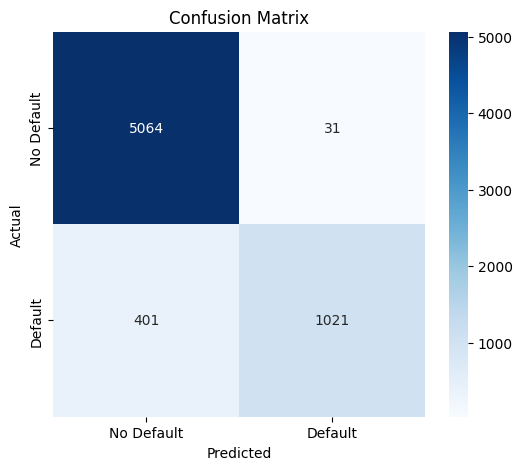

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Default','Default'],
    yticklabels=['No Default','Default']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [31]:
from sklearn.metrics import precision_recall_curve, auc
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
print("Precision-Recall AUC:", pr_auc)

Precision-Recall AUC: 0.8828391749679032


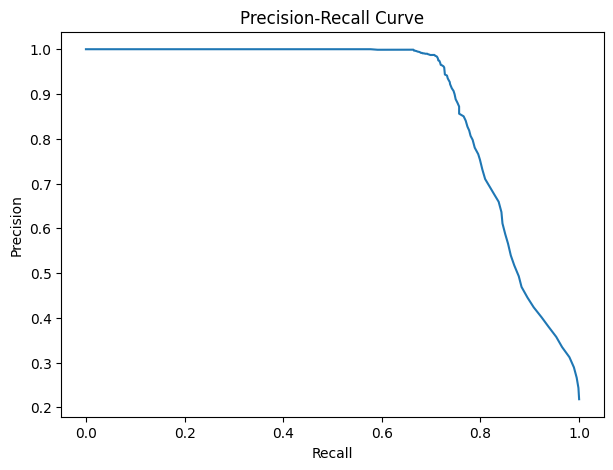

In [32]:
plt.figure(figsize=(7,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## 10. Hyperparameter Tuning

GridSearchCV is used to search for the best combination of Random Forest hyperparameters.

The model is optimized using 5-fold cross-validation with Recall as the scoring metric.

In [33]:
from sklearn.model_selection import GridSearchCV

In [34]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

In [35]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

In [37]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')),
                                                                        ('cat',...
                                                                         Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [10, 20, None],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='recall')

In [38]:
print(grid_search.best_params_)

{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}


In [39]:
print(grid_search.best_score_)

0.7223008472021923


## 11. Evaluate the Optimized Model

The best model obtained from GridSearchCV is evaluated on the unseen test dataset.

In [41]:
# Best model from GridSearchCV
best_model = grid_search.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))


Accuracy : 0.9335583857603191
Precision: 0.9705042816365367
Recall   : 0.7172995780590717
F1 Score : 0.8249090173877881
ROC AUC  : 0.9312382592900847


In [43]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.97      0.72      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.86      0.89      6517
weighted avg       0.94      0.93      0.93      6517



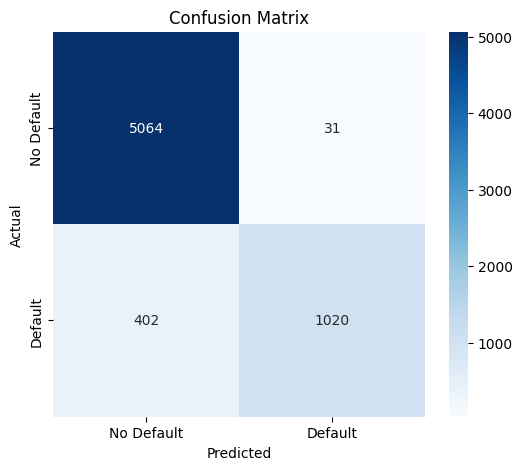

In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Default','Default'],
    yticklabels=['No Default','Default']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [45]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

pr_auc = auc(recall, precision)

print("Precision-Recall AUC:", pr_auc)

Precision-Recall AUC: 0.884170658944143


## 12. Feature Importance Analysis

Random Forest provides feature importance scores that help identify which borrower and loan characteristics contribute most to the prediction of loan default.

In [46]:
# Get the trained Random Forest classifier
rf_model = best_model.named_steps['classifier']

# Get transformed feature names
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
})

# Sort features
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(10)

,Feature,Importance
5,num__loan_percent_income,0.228139
1,num__person_income,0.140344
4,num__loan_int_rate,0.108192
3,num__loan_amnt,0.070277
2,num__person_emp_length,0.059990
10,cat__person_home_ownership_RENT,0.056265
20,cat__loan_grade_D,0.055562
0,num__person_age,0.045105
6,num__cb_person_cred_hist_length,0.034180
7,cat__person_home_ownership_MORTGAGE,0.028203


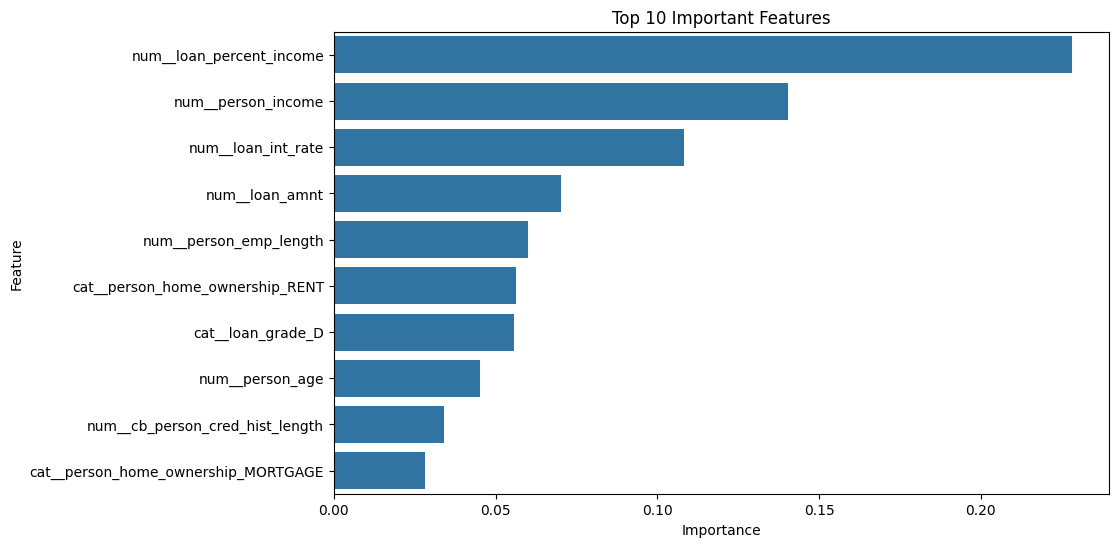

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()

## 13. Save the Trained Model

The final optimized model is saved using Joblib so that it can be loaded later without retraining.

In [48]:
import joblib

joblib.dump(best_model, "credit_risk_model.pkl")

['credit_risk_model.pkl']